In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
# loading EDA data file for feature engineering
df = pd.read_csv("../data/sepsis_EDA.csv")

In [82]:
df.head()

,age,sex,episode,outcome,age_group
0,21,female,1,1,18-40
1,20,female,1,1,18-40
2,21,female,1,1,18-40
3,77,male,1,1,60-80
4,72,male,1,1,60-80


In [83]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [84]:
#Convert Gender to Numeric (For ML)
df['sex'] = df['sex'].map({
    'male':0,
    'female':1
})


In [85]:
df.head()

,age,sex,episode,outcome,age_group
0,21,1,1,1,18-40
1,20,1,1,1,18-40
2,21,1,1,1,18-40
3,77,0,1,1,60-80
4,72,0,1,1,60-80


In [86]:
df['sex'].value_counts()

sex
0    57973
1    52231
Name: count, dtype: int64

In [87]:
print(df['age'].min())
print(df['age'].max())


0
100


In [88]:
df['age'].isna().sum()

np.int64(0)

In [89]:
# Create risk groups
df['age_risk'] = pd.cut(
    df['age'],
    bins=[0,40,60,75,120],
    labels=[0,1,2,3],
    include_lowest=True
)

df[df['age_risk'].isna()]

#0 → low risk
#1 → moderate risk
#2 → high risk
#3 → very high risk

,age,sex,episode,outcome,age_group,age_risk


In [90]:
df.head()

,age,sex,episode,outcome,age_group,age_risk
0,21,1,1,1,18-40,0
1,20,1,1,1,18-40,0
2,21,1,1,1,18-40,0
3,77,0,1,1,60-80,3
4,72,0,1,1,60-80,2


In [91]:
df.dtypes

age             int64
sex             int64
episode         int64
outcome         int64
age_group      object
age_risk     category
dtype: object

In [92]:
# Convert to numeric
df['age_risk'] = df['age_risk'].astype(int)



In [93]:
df.head()

,age,sex,episode,outcome,age_group,age_risk
0,21,1,1,1,18-40,0
1,20,1,1,1,18-40,0
2,21,1,1,1,18-40,0
3,77,0,1,1,60-80,3
4,72,0,1,1,60-80,2


In [94]:
#Create Episode Category
df['episode_category'] = pd.cut(
    df['episode'],
    bins=[0,1,3,10],
    labels=[0,1,2],
    include_lowest=True
)

#0 → first episode
#1 → repeated episodes
#2 → frequent episodes

In [95]:
df['episode_category'] = df['episode_category'].astype(int)

In [96]:
df.head()

,age,sex,episode,outcome,age_group,age_risk,episode_category
0,21,1,1,1,18-40,0,0
1,20,1,1,1,18-40,0,0
2,21,1,1,1,18-40,0,0
3,77,0,1,1,60-80,3,0
4,72,0,1,1,60-80,2,0


In [97]:
#Create Age × Episode Interaction Feature
df['age_episode_interaction'] = df['age'] * df['episode']

In [98]:
df.head()

,age,sex,episode,outcome,age_group,age_risk,episode_category,age_episode_interaction
0,21,1,1,1,18-40,0,0,21
1,20,1,1,1,18-40,0,0,20
2,21,1,1,1,18-40,0,0,21
3,77,0,1,1,60-80,3,0,77
4,72,0,1,1,60-80,2,0,72


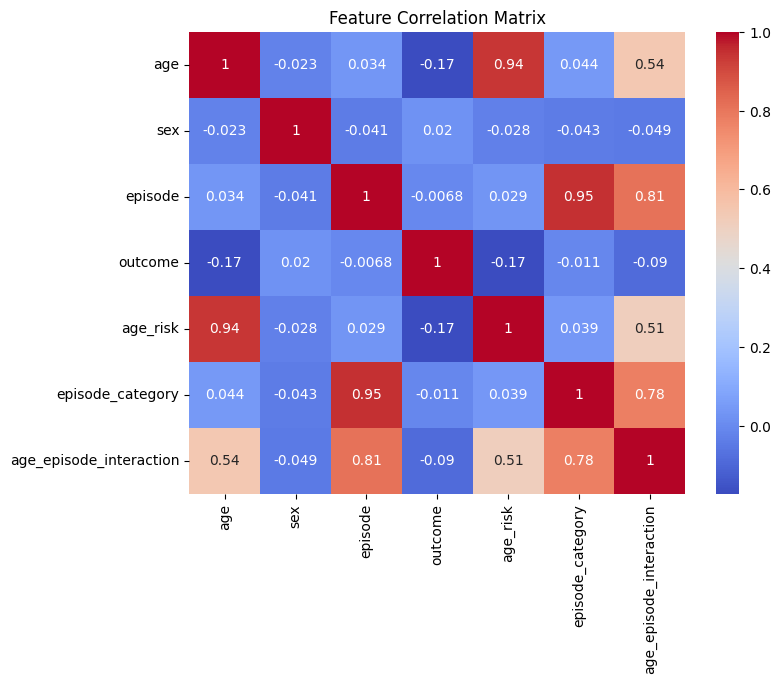

In [99]:
#Correlation Check (Important Before Modeling)

corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [100]:
# Risk ratio of age risk groups 
risk_table = pd.crosstab(df['age_group'], df['outcome'], normalize='index')

print(risk_table)


outcome           0         1
age_group                    
0-18       0.006538  0.993462
18-40      0.007504  0.992496
40-60      0.033548  0.966452
60-80      0.078257  0.921743
80+        0.137559  0.862441


This shows elderly has more Mortality rate

Relationship With Target (outcome)


Feature	Correlation with Outcome	Meaning
age	-0.17	Older patients slightly more likely to die
sex	0.02	Almost no effect
episode	-0.006	Almost no effect
age_risk	-0.17	Same pattern as age
episode_category	-0.01	Very weak
age_episode_interaction	-0.09	Some weak relationship

Insight
Age is the most useful predictor in this dataset.
Sex and episode contribute very little.

In [101]:
#final data set for modelling
df_model = df[[
    'age',
    'sex',
    'episode',
    'age_episode_interaction',
    'outcome'
]]

In [102]:
df_model.head()

,age,sex,episode,age_episode_interaction,outcome
0,21,1,1,21,1
1,20,1,1,20,1
2,21,1,1,21,1
3,77,0,1,77,1
4,72,0,1,72,1


In [103]:
#checking model data
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110204 entries, 0 to 110203
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   age                      110204 non-null  int64
 1   sex                      110204 non-null  int64
 2   episode                  110204 non-null  int64
 3   age_episode_interaction  110204 non-null  int64
 4   outcome                  110204 non-null  int64
dtypes: int64(5)
memory usage: 4.2 MB


In [104]:
# saving data set fo modeling
df_model.to_csv("../data/sepsis_model_data.csv", index=False)